# Kenny Courser Summer 2023

# 1

## For $l>t$, our integral becomes:
## $P= \int_{0}^{\pi /2} \int_{0}^{m(\theta)} \frac{4}{t \pi} dx d \theta$ where $m(\theta)=\min \{ \frac{l}{2} \sin(\theta), \frac{t}{2} \}$. We break this integral up into two cases: Case 1 is when $t > l \sin (\theta)$, so that $\sin^{-1}(\frac{t}{l}) > \theta$, and Case 2 is when $t < l \sin (\theta)$, so that $\sin^{-1}(\frac{t}{l}) < \theta < \frac{\pi}{2}$. Note that in Case 1, when $t > l \sin (\theta)$, we have $m(\theta)=\frac{l}{2} \sin (\theta)$ and in Case 2, when $t < l \sin (\theta)$, we have $m(\theta)=\frac{t}{2}$.

## Thus, our integral becomes,
## $P = \int_{0}^{\sin^{-1} (\frac{t}{l})} \int_{0}^{\frac{l}{2} \sin(\theta)} \frac{4}{t \pi} dx d \theta + \int_{\sin^{-1}(\frac{t}{l})}^{\frac{\pi}{2}} \int_{0}^{\frac{t}{2}} \frac{4}{t \pi} dx d \theta$
## $= \int_{0}^{\sin^{-1}( \frac{t}{l})} \frac{2l}{t \pi} \sin (\theta) d \theta + \int_{\sin^{-1}(\frac{t}{l})}^{\frac{\pi}{2}} \frac{2}{\pi} d \theta$
## $= \frac{2}{\pi} ( \frac{l - \sqrt{l^2-t^2}}{t} + \cos^{-1}(\frac{t}{l}))$ 

# 2

In [44]:
import random
import math

def monte_carlo_buffons_needle(l, t, num_trials):
    if l >= t:
        raise ValueError("Needle length (l) should be less than the distance between lines (t) for the short needle case.")

    crossing_count = 0

    for _ in range(num_trials):
        # Generate a random position of the needle's center (0 to t) and a random angle (-90 to 90 degrees).
        center = random.uniform(0, t)
        angle = random.uniform(-(math.pi)/2, math.pi/2)

        # Calculate the position of both ends of the needle.
        x1 = center - (l / 2) * math.cos(angle)
        x2 = center + (l / 2) * math.cos(angle)

        # Check if the needle crosses a line.
        if (0 < x1 < t and x2 > t) or (0 < x2 < t and x1 < 0) or (0 < x2 < t and x1 > t) or (0 < x1 < t and x2 < 0):
            crossing_count += 1

    # Calculate the probability P.
    probability = crossing_count / num_trials
    return probability

In [50]:
probability_crossing_line = monte_carlo_buffons_needle(2,3,1000000)
pi_estimate = (2 * 2) / (probability_crossing_line * 3)
pi_estimate

3.1419345362229705

# 3

## In the long needle case $(l > t)$, we have to allow for the possibility that $x_1<0$ and $x_2>t$ as well as $x_1>t$ and $x_2<0$. These cases correspond to the events that one end of the needle crosses one line and the other end of the needle crosses an adjacent line.

In [2]:
def monte_carlo_buffons_needle_general(l, t, num_trials):

    crossing_count = 0

    for _ in range(num_trials):
        # Generate a random position of the needle's center (0 to t) and a random angle (-90 to 90 degrees).
        center = random.uniform(0, t)
        angle = random.uniform(-(math.pi)/2, math.pi/2)

        # Calculate the position of both ends of the needle.
        x1 = center - (l / 2) * math.cos(angle)
        x2 = center + (l / 2) * math.cos(angle)

        # Check if the needle crosses a line.
        if (0 < x1 < t and x2 > t) or (0 < x2 < t and x1 < 0) or (0 < x2 < t and x1 > t) or (0 < x1 < t and x2 < 0) or (x1 < 0 and x2 > t) or (x2 < 0) and (x1 > t):
            crossing_count += 1

    # Calculate the probability P.
    probability = crossing_count / num_trials
    return probability

## Needle length 50, width strip 5 should have a very high probability of crossing:

In [59]:
probability_crossing_line2 = monte_carlo_buffons_needle_general(50,5,1000000)
probability_crossing_line2

0.968196

# 4

## We're going to fix $t=1$ and let $l$ vary to scale the $\frac{l}{t}$ ratio.

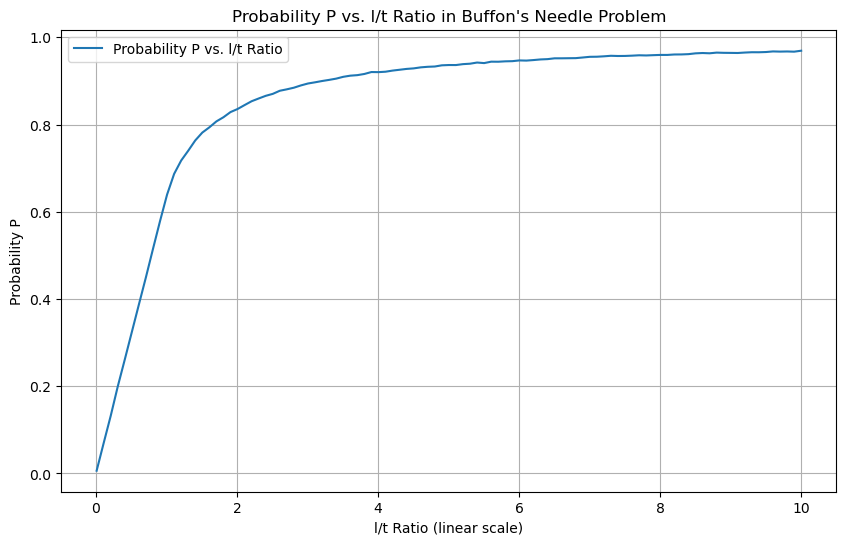

In [7]:
import random
import math
import matplotlib.pyplot as plt

if __name__ == "__main__":
    t = 1.0  # Distance between the parallel lines (fixed at 1)
    num_simulations = 100000  # Number of Monte Carlo simulations

    # Prepare lists to store values for plotting
    l_values = []
    p_values = []

    # Vary l from 0.01 to 10 with 100 increments (linear scale)
    for i in range(101):
        l = 0.01 + i * (10 - 0.01) / 100  # Vary l linearly from 0.01 to 10
        l_values.append(l)

        probability_crossing_line = monte_carlo_buffons_needle_general(l, t, num_simulations)
        p_values.append(probability_crossing_line)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(l_values, p_values, label="Probability P vs. l/t Ratio")
    plt.xlabel("l/t Ratio (linear scale)")
    plt.ylabel("Probability P")
    plt.title("Probability P vs. l/t Ratio in Buffon's Needle Problem")
    plt.grid()
    plt.legend()
    plt.show()

# 5

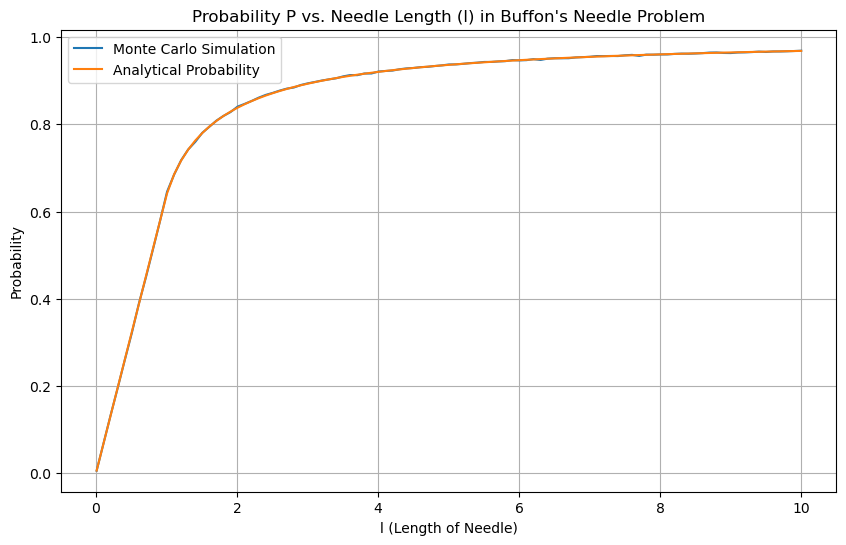

In [12]:
import random
import math
import matplotlib.pyplot as plt


def analytical_probability(l, t):
    if l >= t:
        return 2 / math.pi * ((l - math.sqrt(l**2 - t**2)) / t + math.acos(t / l))
    else:
        return 2 * l / (math.pi * t)

if __name__ == "__main__":
    t = 1.0  # Distance between the parallel lines (fixed at 1)
    num_simulations = 100000  # Number of Monte Carlo simulations

    # Prepare lists to store values for plotting
    l_values = []
    p_values = []
    analytical_p_values = []

    # Vary l from 0.01 to 10 with 100 increments (linear scale)
    for i in range(101):
        l = 0.01 + i * (10 - 0.01) / 100  # Vary l linearly from 0.01 to 10
        l_values.append(l)

        probability_crossing_line = monte_carlo_buffons_needle_general(l, t, num_simulations)
        p_values.append(probability_crossing_line)

        analytical_p = analytical_probability(l, t)
        analytical_p_values.append(analytical_p)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(l_values, p_values, label="Monte Carlo Simulation")
    plt.plot(l_values, analytical_p_values, label="Analytical Probability")
    plt.xlabel("l (Length of Needle)")
    plt.ylabel("Probability")
    plt.title("Probability P vs. Needle Length (l) in Buffon's Needle Problem")
    plt.grid()
    plt.legend()
    plt.show()

## The two curves above are nearly identical. The blue curve is difficult to see since it's hiding underneath the orange curve. I'm going to plot them again below but with less MC simulations so that the blue curve is more visible.

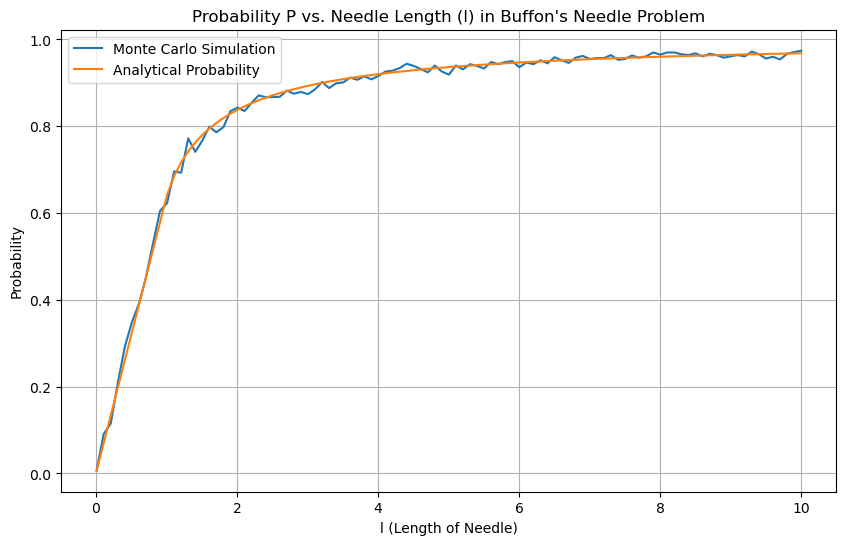

In [14]:
import random
import math
import matplotlib.pyplot as plt


def analytical_probability(l, t):
    if l >= t:
        return 2 / math.pi * ((l - math.sqrt(l**2 - t**2)) / t + math.acos(t / l))
    else:
        return 2 * l / (math.pi * t)

if __name__ == "__main__":
    t = 1.0  # Distance between the parallel lines (fixed at 1)
    num_simulations = 1000  # Number of Monte Carlo simulations

    # Prepare lists to store values for plotting
    l_values = []
    p_values = []
    analytical_p_values = []

    # Vary l from 0.01 to 10 with 100 increments (linear scale)
    for i in range(101):
        l = 0.01 + i * (10 - 0.01) / 100  # Vary l linearly from 0.01 to 10
        l_values.append(l)

        probability_crossing_line = monte_carlo_buffons_needle_general(l, t, num_simulations)
        p_values.append(probability_crossing_line)

        analytical_p = analytical_probability(l, t)
        analytical_p_values.append(analytical_p)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(l_values, p_values, label="Monte Carlo Simulation")
    plt.plot(l_values, analytical_p_values, label="Analytical Probability")
    plt.xlabel("l (Length of Needle)")
    plt.ylabel("Probability")
    plt.title("Probability P vs. Needle Length (l) in Buffon's Needle Problem")
    plt.grid()
    plt.legend()
    plt.show()